<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Scikit_Learn_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First we will Implement linear regression using sklearn and then we will use gradient descent with linear regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
# Manual dataset with single feature

x_train = np.array([1.0,2.0]) # Size
y_train = np.array([300,500]) # Price(target Value)

In [5]:
from sklearn import linear_model
#Scikit learn linear regression module first creates a regression object
# Next it uses the object by the help of fit function performing the regression and the  fitting
# It expects a 2D matrix as input

linear_model = LinearRegression()
linear_model.fit(x_train.reshape(-1,1),y_train)

LinearRegression()

In [6]:
# w - referred as coefficient and b as intercept
b = linear_model.intercept_
w = linear_model.coef_
print(f"w = {w:} , b = {b:.02f}" )
print(f"Manual Value Prediction : f_wb = wx + b : {1200*w + b}")

w = [200.] , b = 100.00
Manual Value Prediction : f_wb = wx + b : [240100.]


Using Multiple Features - Here we are using close form solution while it is very useful but it can be computationally costly in larger datasets

In [7]:
# Load the dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_From_Scratch/01_Regression/house_features_dataset.csv")
data = np.loadtxt("/content/drive/MyDrive/Colab Notebooks/ML_From_Scratch/01_Regression/house_features_dataset.csv",delimiter=',',skiprows=1)

X_train = data[:,:4]
Y_train = data[:,4]
X_features  =['size','bedrooms','floors','age']

In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train,Y_train)

b = linear_model.intercept_
w = linear_model.coef_
print(f"w = {w:} , b = {b:0.2f}")

w = [ 0.23128876 -2.18839388 12.23508617  1.86805483] , b = -125.82


In [10]:
#Prediction on the dataset

print(f"Prediction on training set : \n{linear_model.predict(X_train)[:4]}")
print(f"Prediction using w and b  \n {(X_train @ w + b)[:4]}")
print(f"Target values \n {Y_train[:4]}")

Prediction on training set : 
[187.6073239  454.33158821 136.86547355 608.44116311]
Prediction using w and b  
 [187.6073239  454.33158821 136.86547355 608.44116311]
Target values 
 [220. 450. 140. 610.]


In [13]:
# Predict the price of an unknown data

x_house = np.array([1200,3,1,40]).reshape(-1,4)
x_price_predict = linear_model.predict(x_house)[0]
print(f"Predicted price of the house is  : {(x_price_predict)*1000:0.2f}")

Predicted price of the house is  : 232120.30


Linear Regression Using StandardScaler and Gradient Descent of sklearn

In [14]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import  StandardScaler

In [19]:
# Scikit-learn has a gradient descent regression model [sklearn.linear_model.SGDRegressor]
# Model performs best with normalized inputs. [sklearn.preprocessing.StandardScaler]

X1_train = data[:,:4]
Y1_train = data[:,4]
X_features  =['size','bedrooms','floors','age']

In [20]:
# Scale/Normalize the training set

scaler = StandardScaler()
X_norm = scaler.fit_transform(X1_train)
print(f"Peak to peak range by column in Original : {np.ptp(X_train,axis=0)}")
print(f"Peak to peak range by column in Normalized : {np.ptp(X_norm,axis=0)}")

Peak to peak range by column in Original : [3.2e+03 4.0e+00 2.0e+00 3.4e+01]
Peak to peak range by column in Normalized : [3.33338985 3.3478958  3.01511345 3.54783145]


In [21]:
# Creating and then fitting the regressor model

sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm,Y_train)
print(sgdr)
print(f"No of iterations completed {sgdr.n_iter_} , no of weight updates : {sgdr.t_}")

SGDRegressor()
No of iterations completed 1000 , no of weight updates : 20001.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [24]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:w: {w_norm}, b:{b_norm}")

model parameters:w: [169.07567386  34.11868515  29.77614527  20.97626428], b:[394.02051725]


In [25]:
# Prediction using sgdr predict()
y_pred_sgdr = sgdr.predict(X_norm)
y_pred = np.dot(X_norm,w_norm) + b_norm
print(f"Prediction using sgdr and w,b :{(y_pred == y_pred_sgdr).all()}")

print(f"Prediction on training set : \n{y_pred[:4]}")
print(f"Target values : \n{Y_train[:4]}")


Prediction using sgdr and w,b :True
Prediction on training set : 
[182.74781687 474.20981296 125.3806116  619.48620676]
Target values : 
[220. 450. 140. 610.]


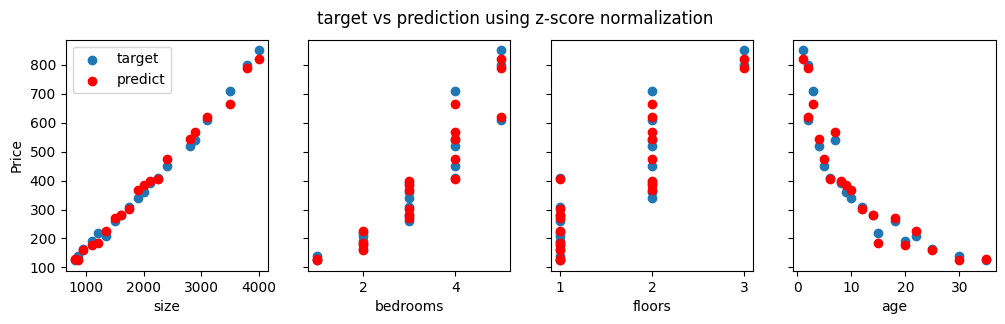

In [28]:
# Plotting the predictions and target vs original features

fig , ax = plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
  ax[i].scatter(X1_train[:,i],Y_train,label = "target")
  ax[i].set_xlabel(X_features[i])
  ax[i].scatter(X1_train[:,i],y_pred,color="red",label = 'predict')

ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("target vs prediction using z-score normalization")
plt.show()